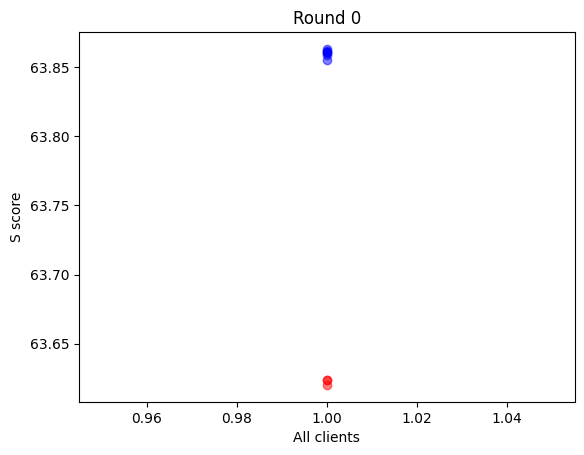

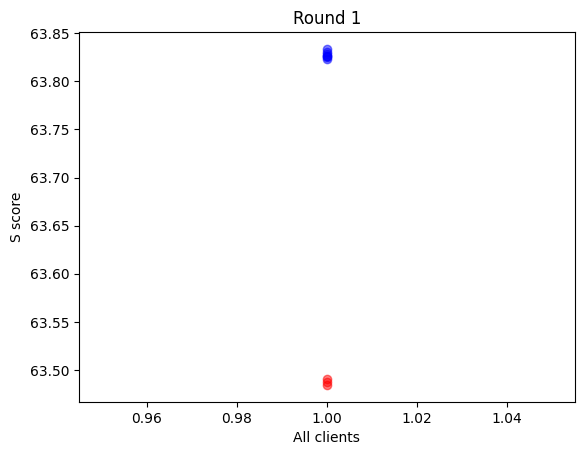

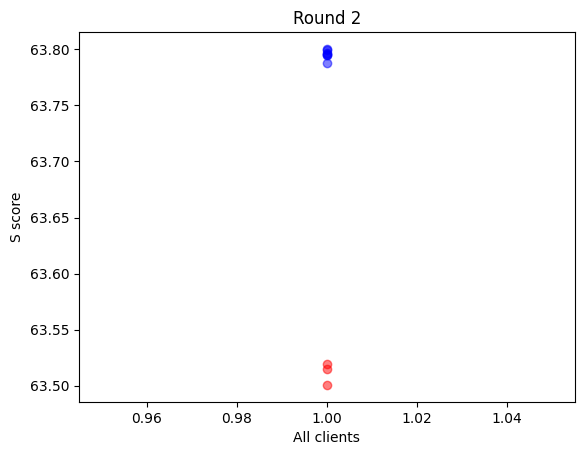

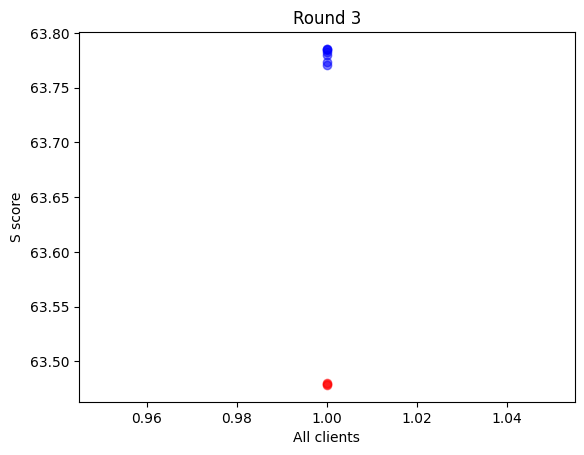

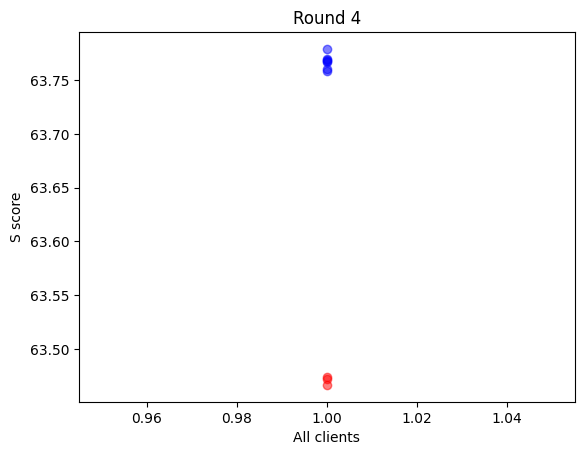

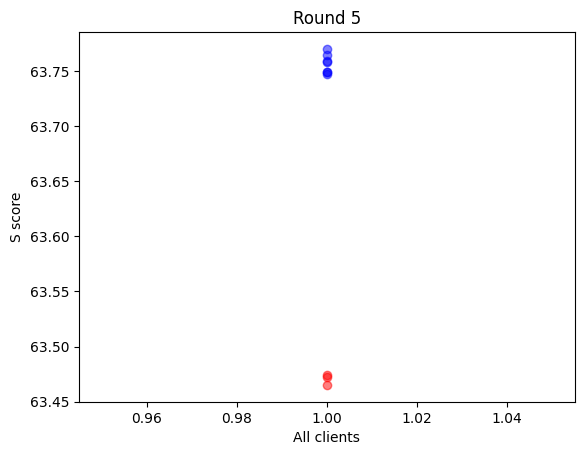

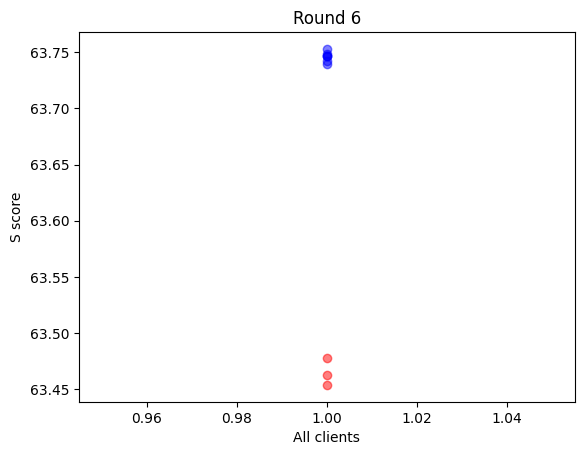

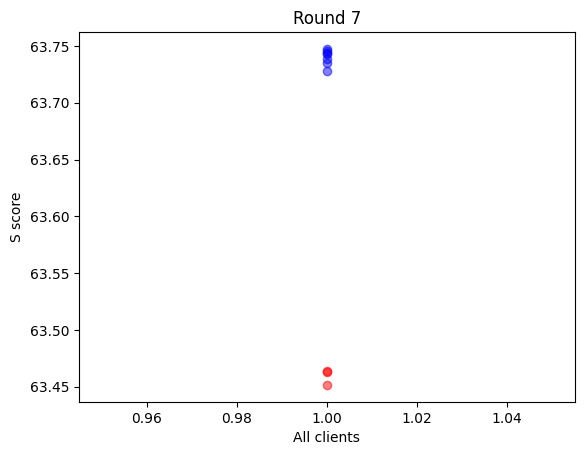

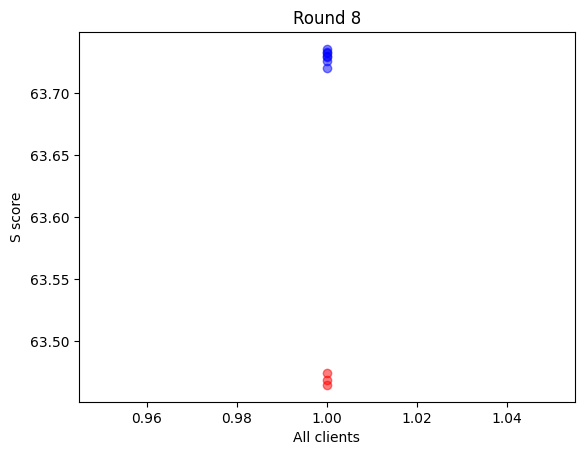

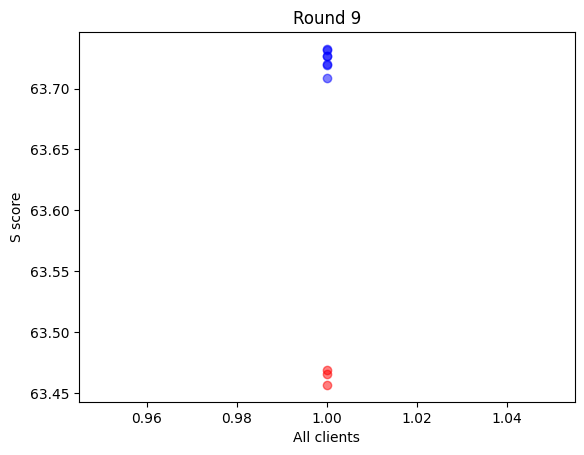

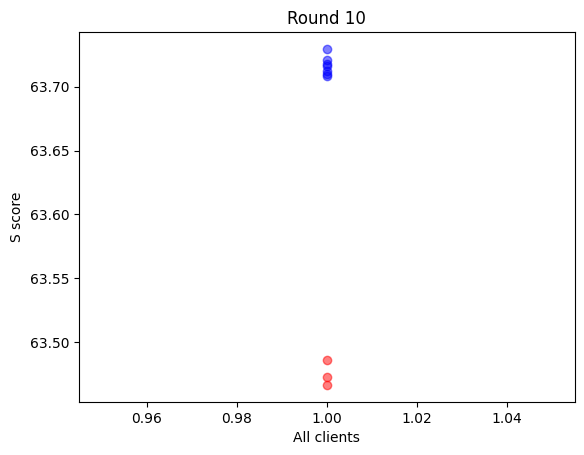

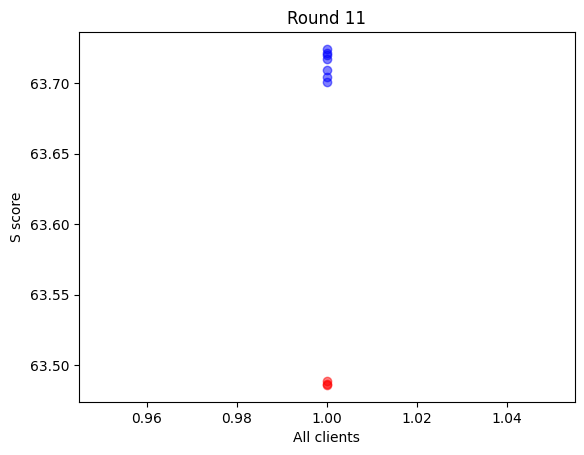

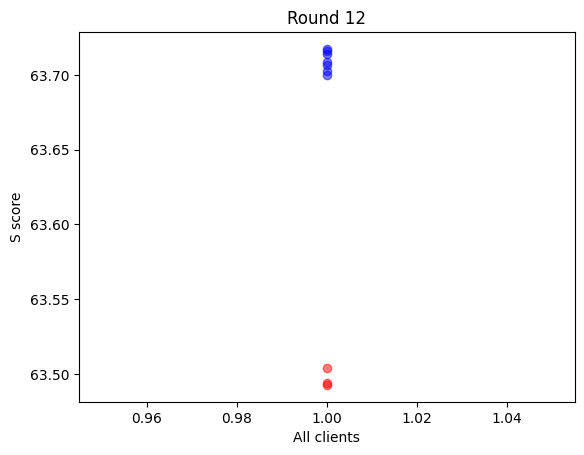

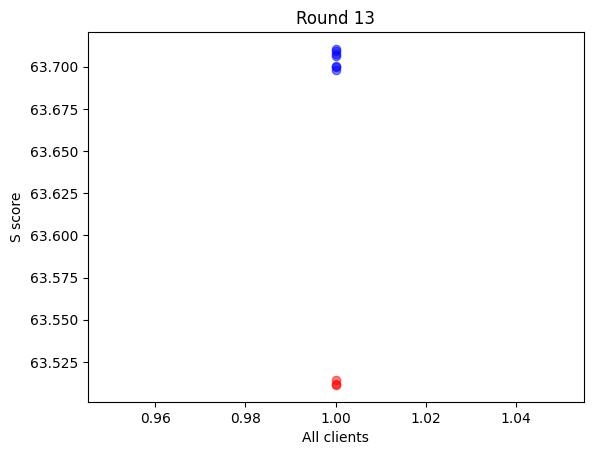

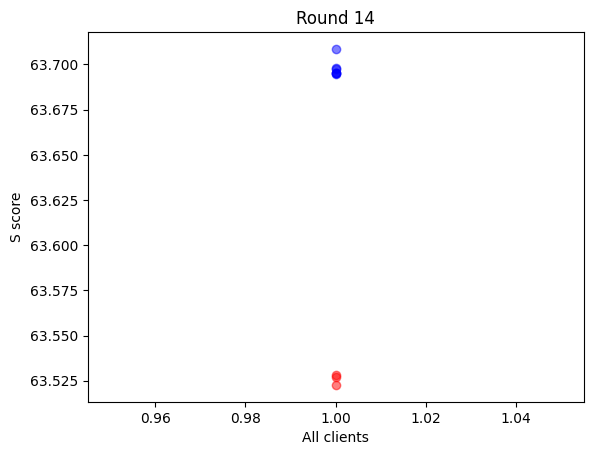

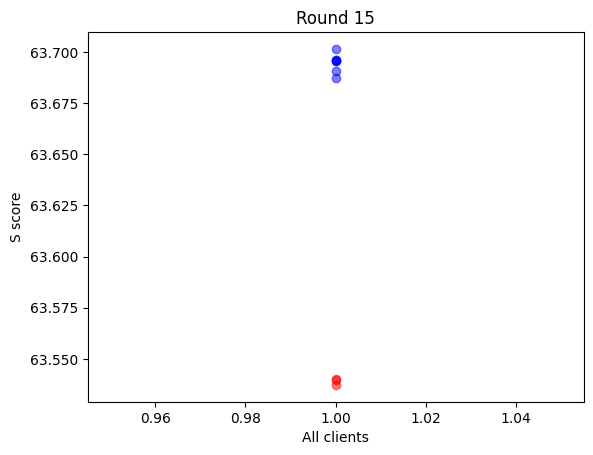

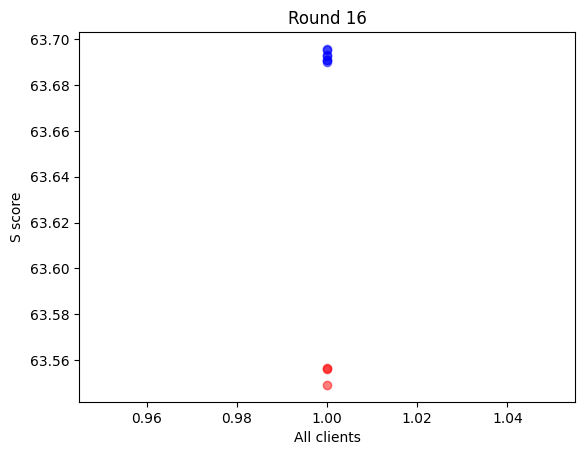

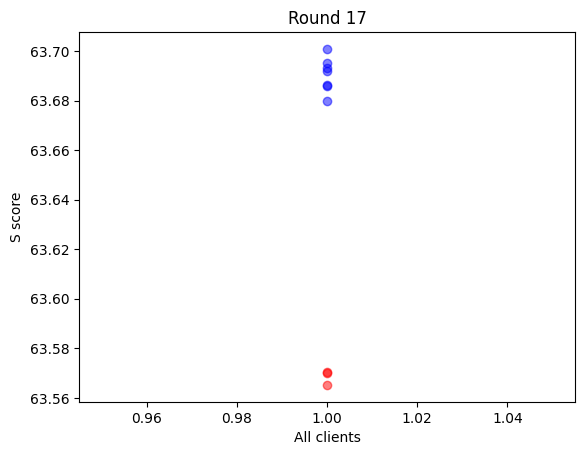

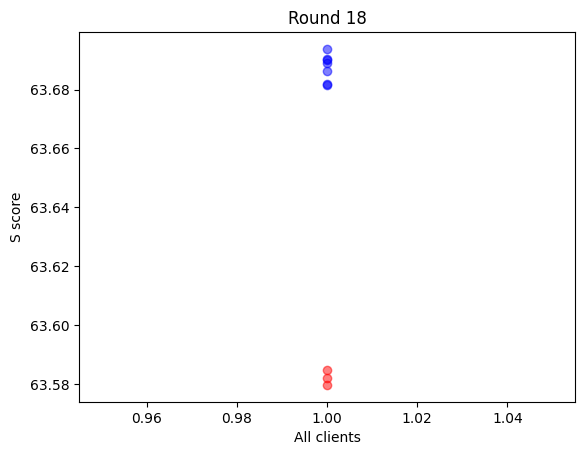

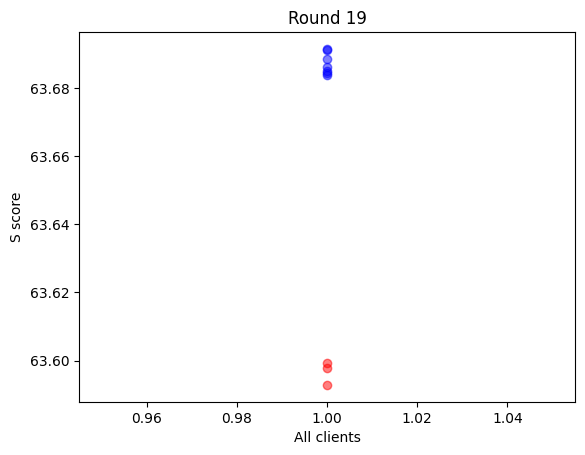

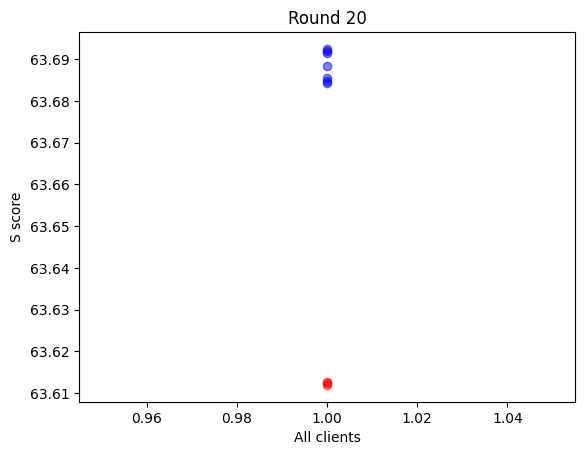

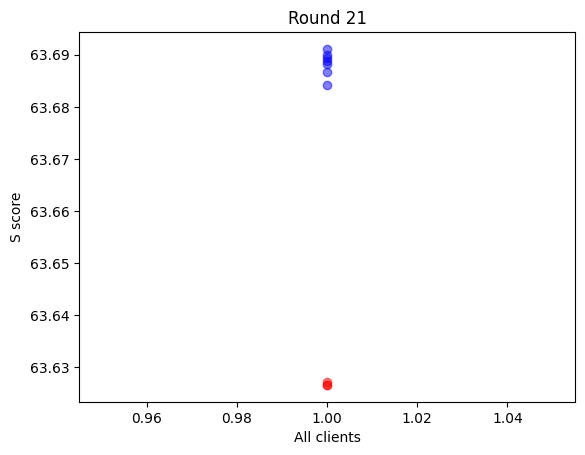

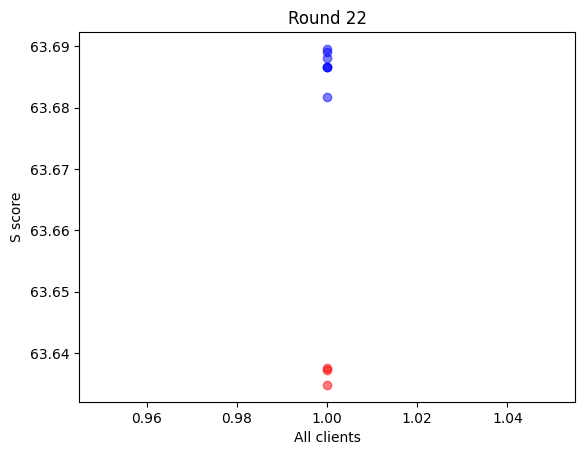

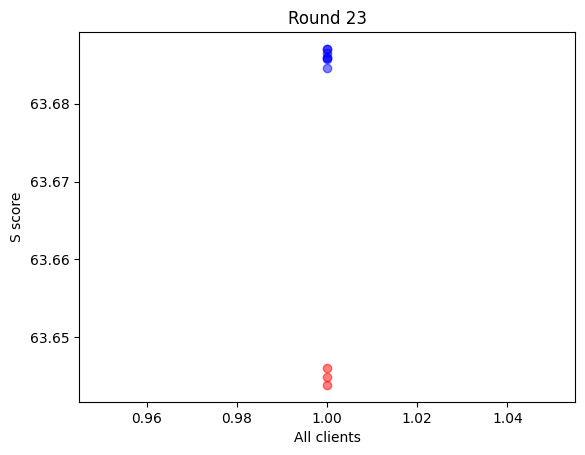

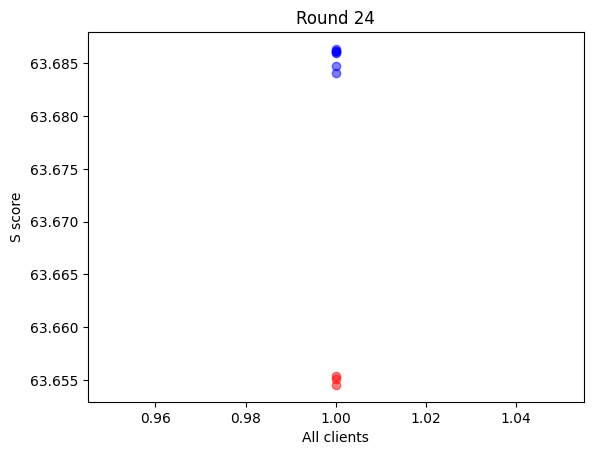

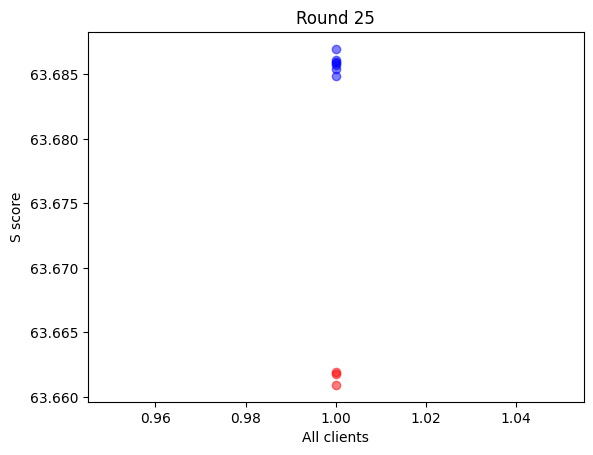

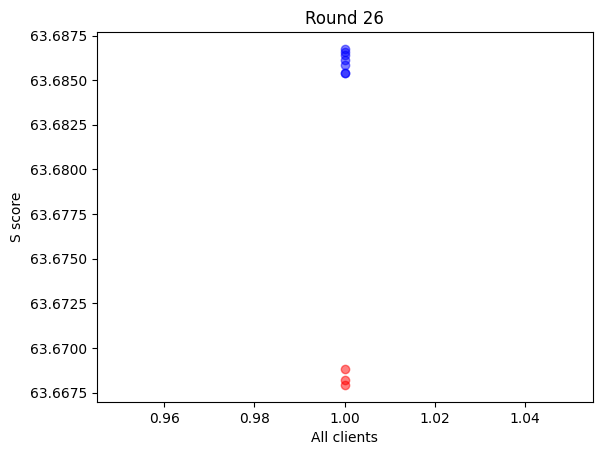

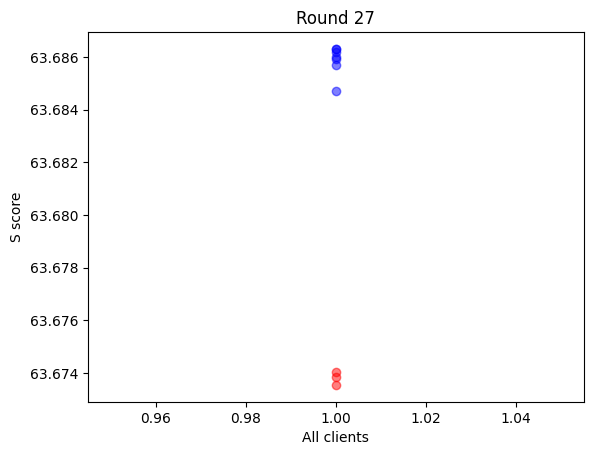

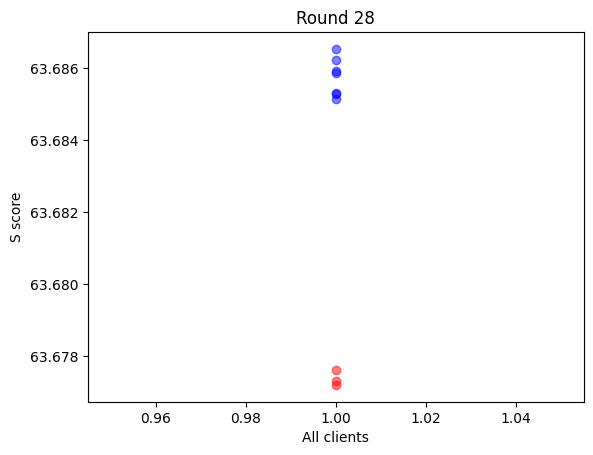

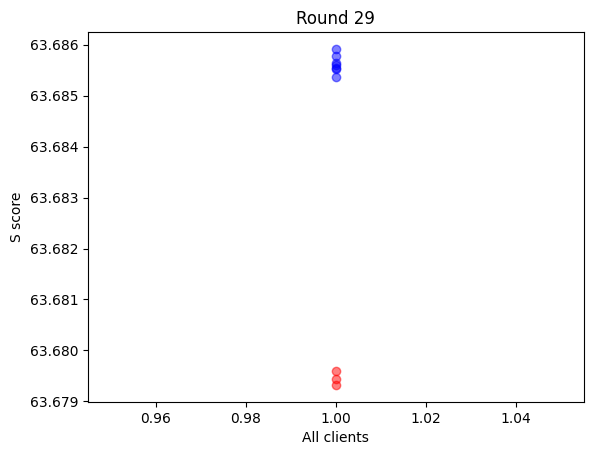

In [4]:
import os
import json
import matplotlib.pyplot as plt
benign = [0,1,2,3,4,5,6]
malicious = [7, 8,9]

folder_path = "/home/ps9044/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][rajpurkar/squad_v2]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]"

for round in range(30):
    file = os.path.join(folder_path, f'round_{round}_safelora_gmm.json')
    with open(file, 'r') as f:
        data = json.load(f)
    
    S_total = data['S_total']
    marker = 'o'
    for i, S in enumerate(S_total):
        plt.scatter(1, S, color='blue' if int(i) in benign else 'red', alpha=0.5, marker=marker)
    
    plt.ylabel('S score')
    plt.xlabel('All clients')
    plt.title('Round {}'.format(round))

    plt.show()


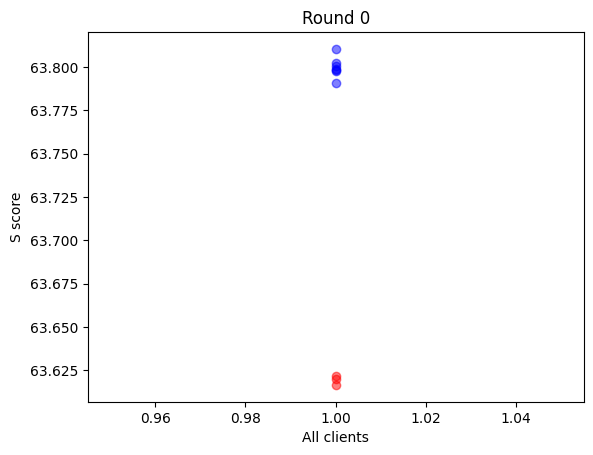

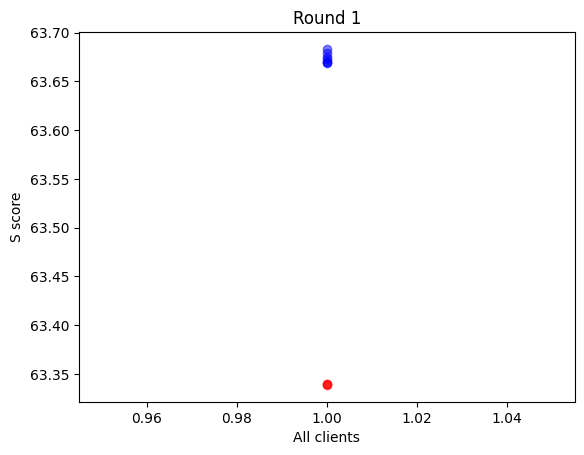

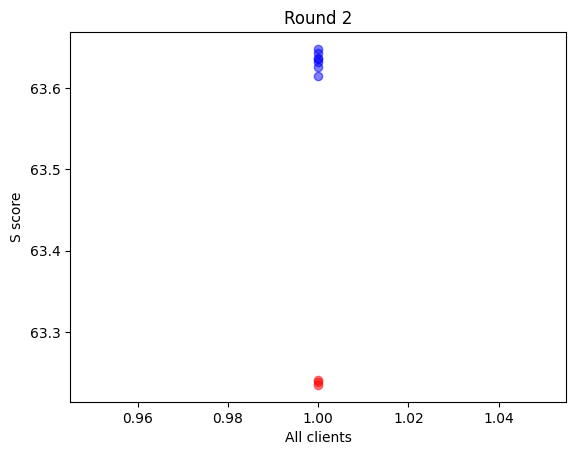

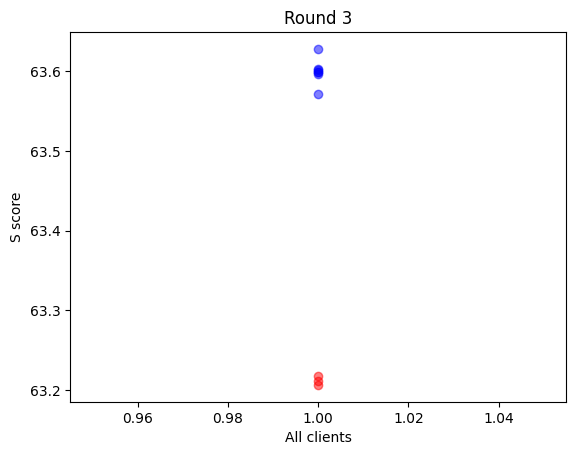

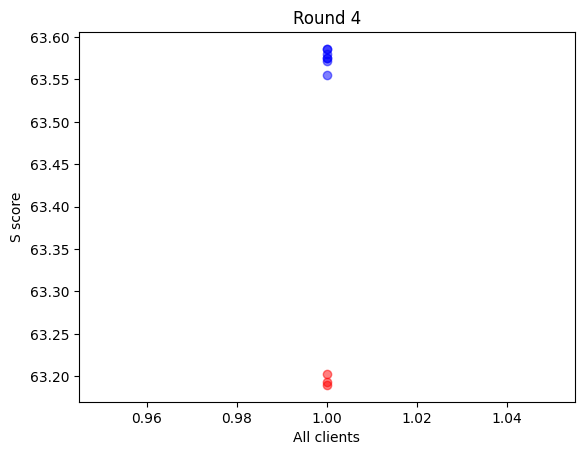

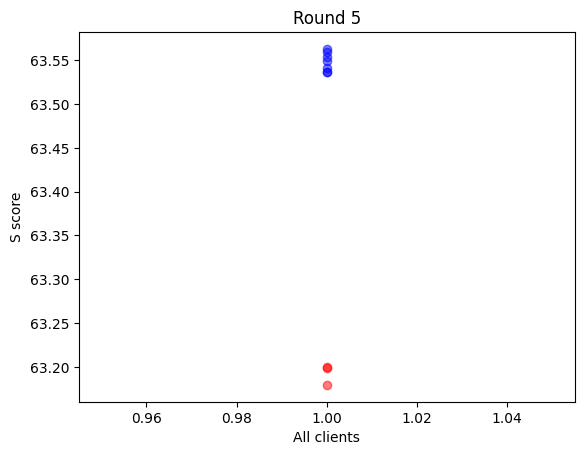

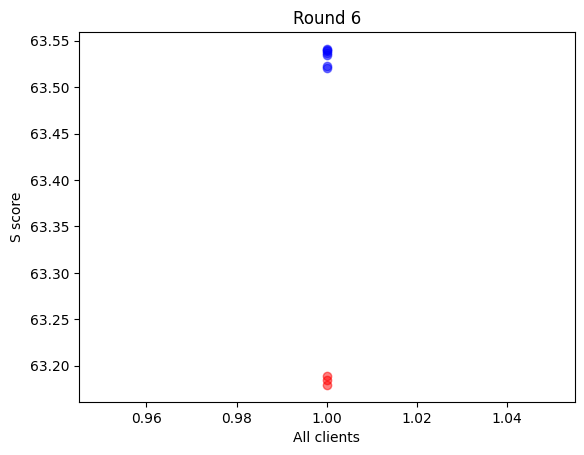

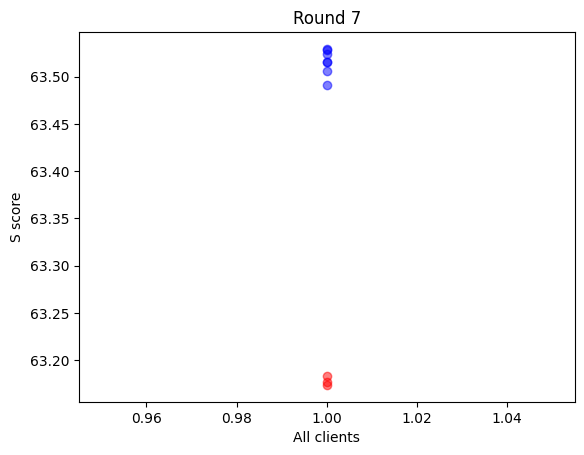

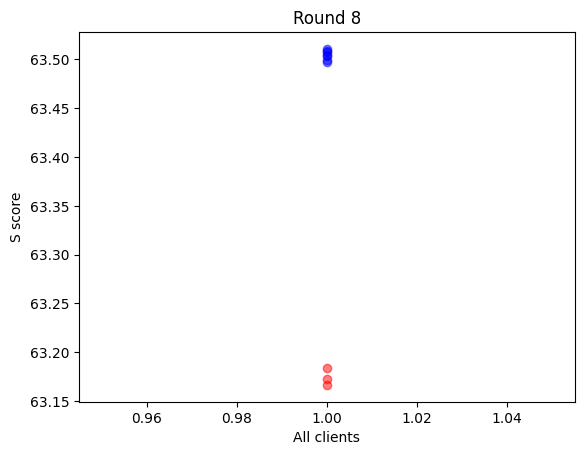

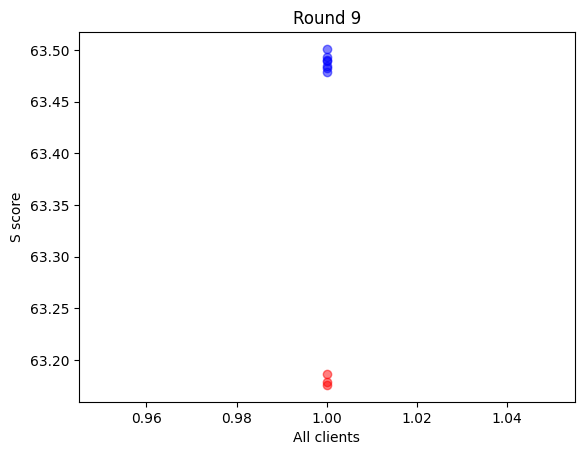

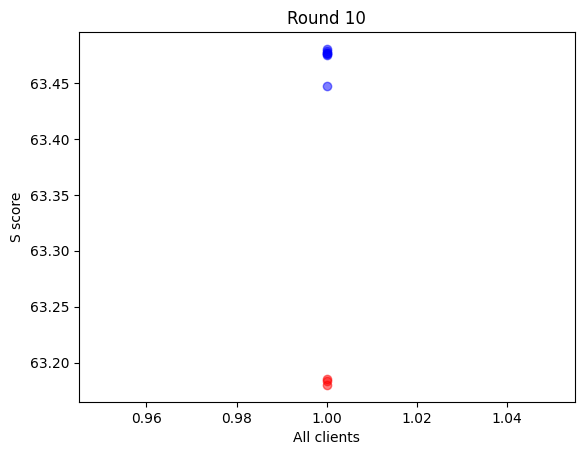

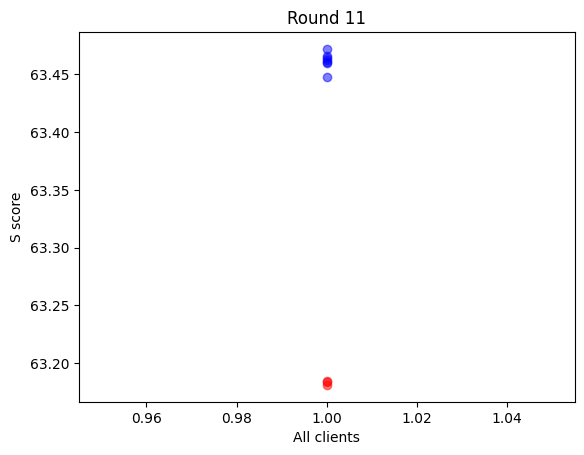

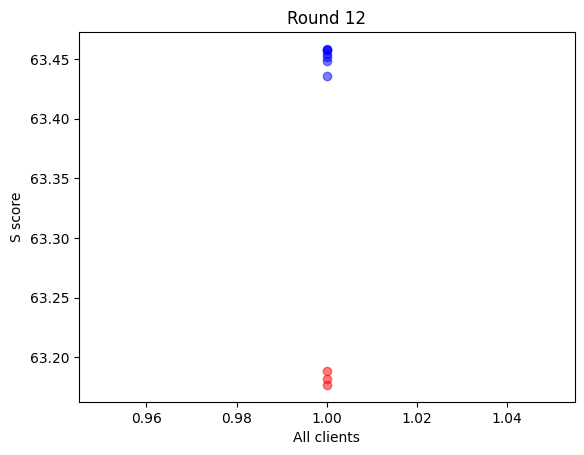

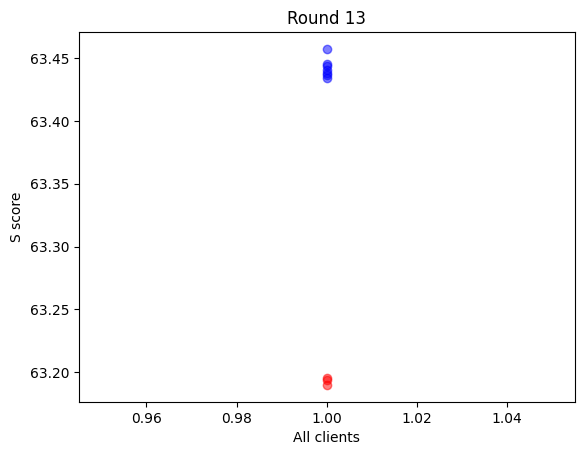

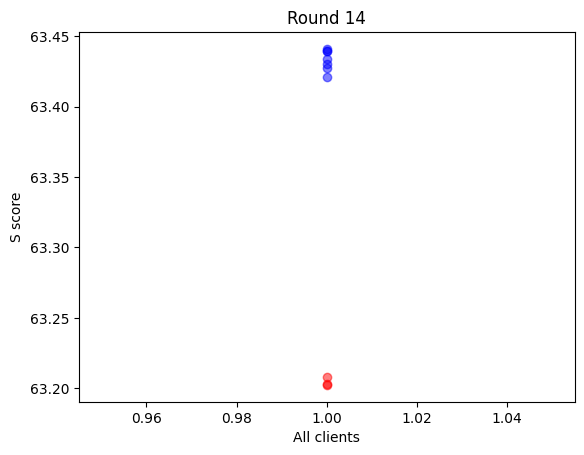

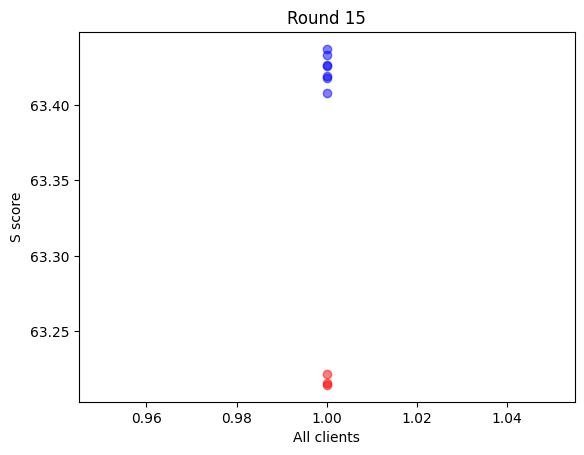

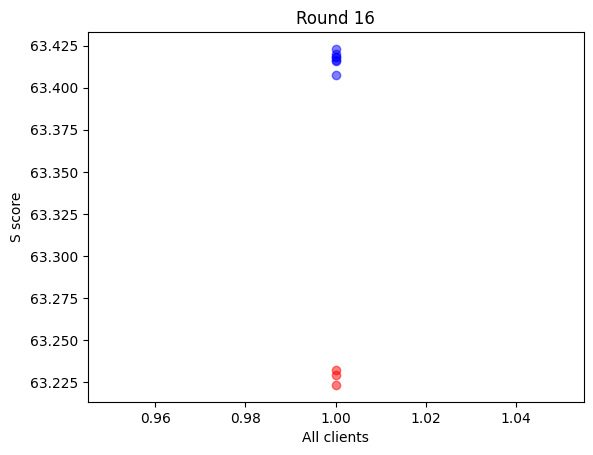

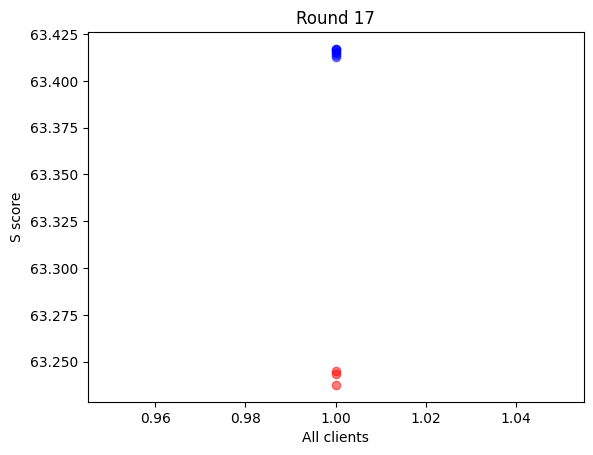

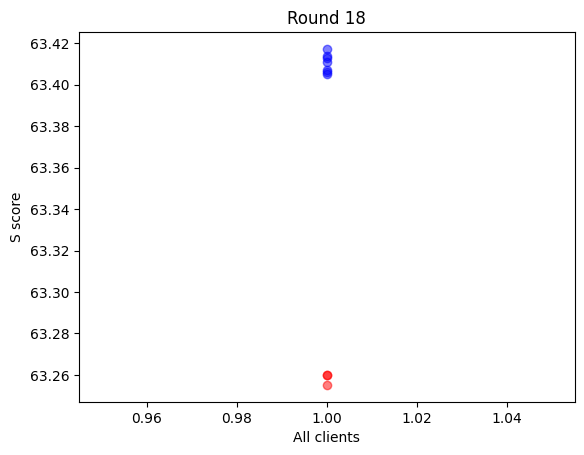

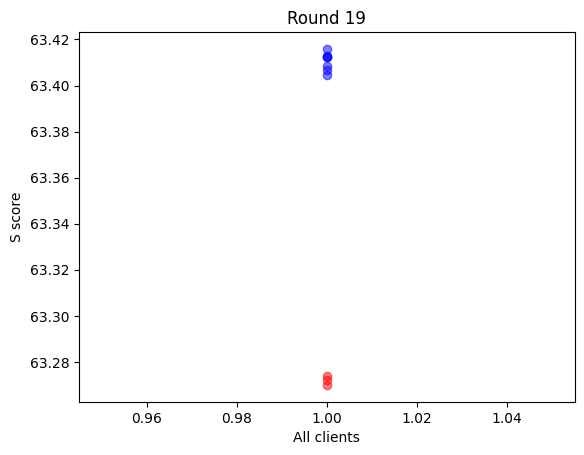

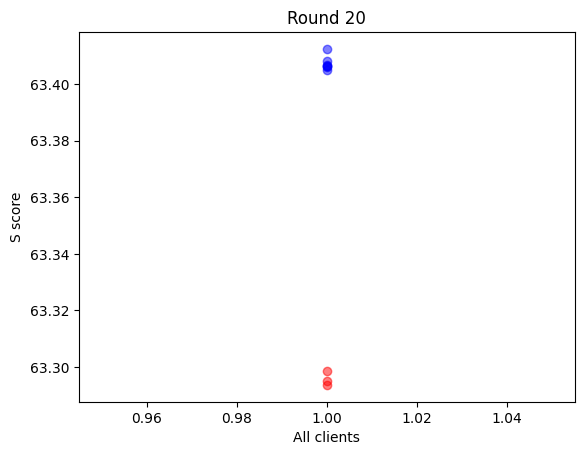

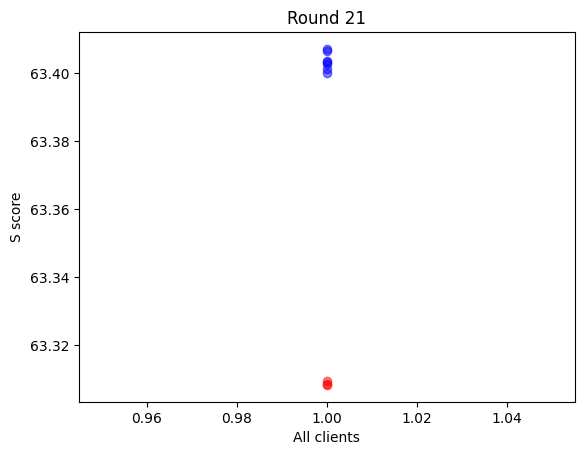

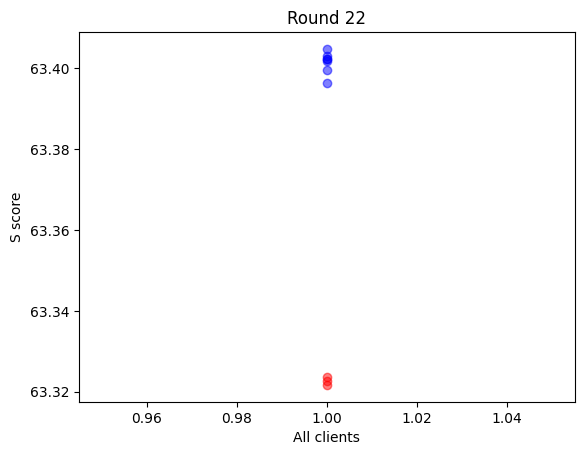

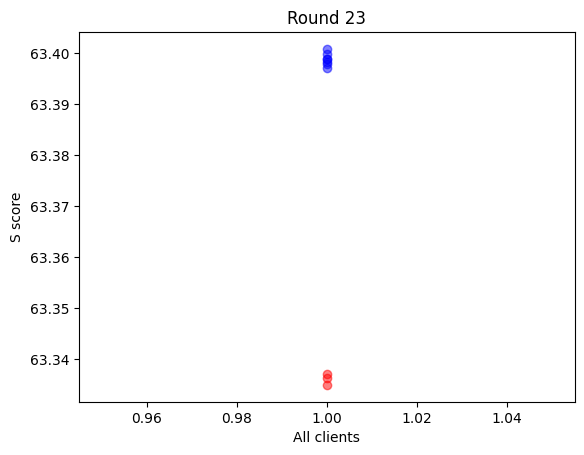

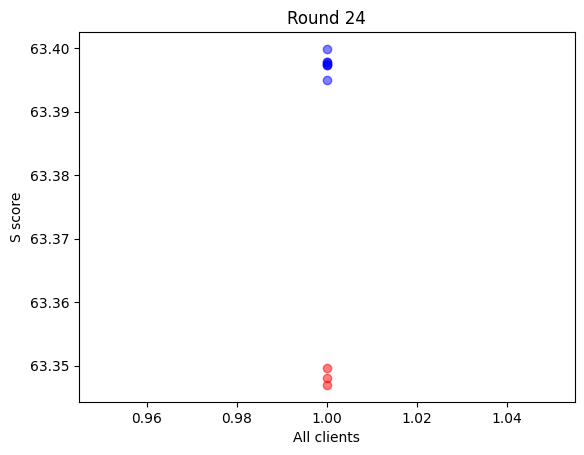

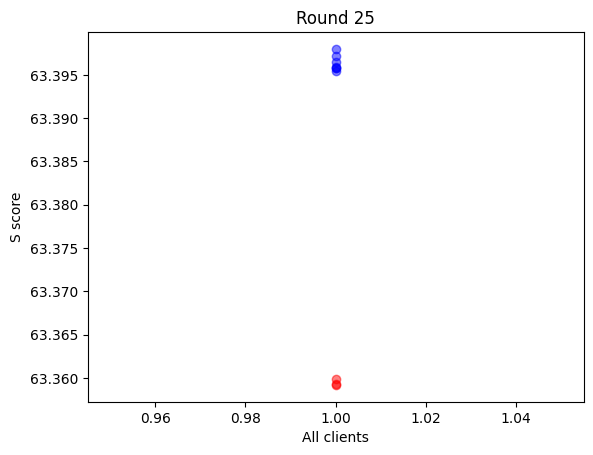

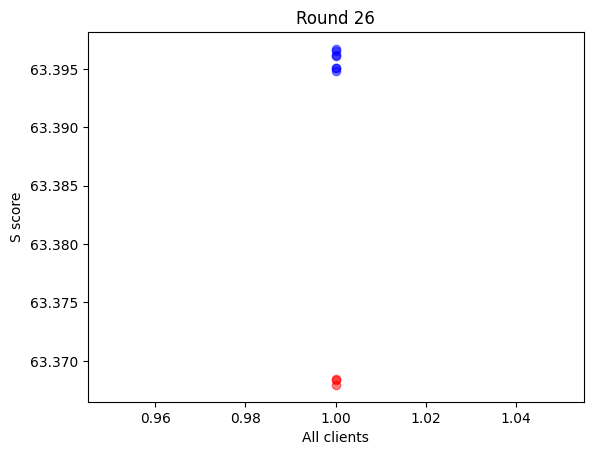

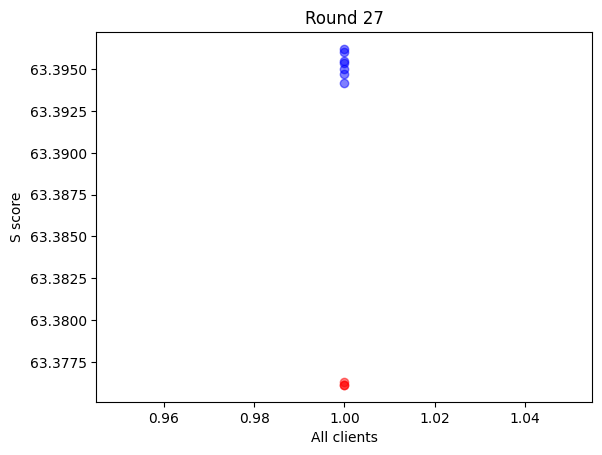

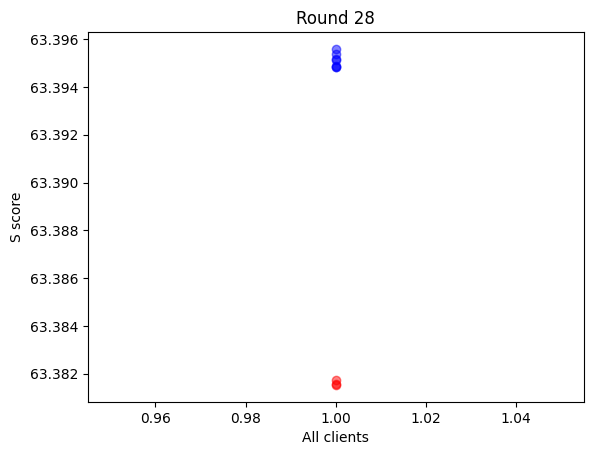

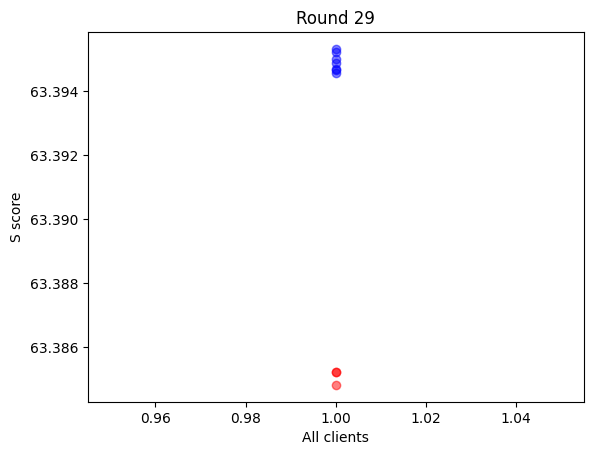

In [5]:
import os
import json
import matplotlib.pyplot as plt
benign = [0,1,2,3,4,5,6]
malicious = [7, 8,9]

folder_path = "/home/ps9044/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][qiaojin/PubMedQA]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]"

for round in range(30):
    file = os.path.join(folder_path, f'round_{round}_safelora_gmm.json')
    with open(file, 'r') as f:
        data = json.load(f)
    
    S_total = data['S_total']
    marker = 'o'
    for i, S in enumerate(S_total):
        plt.scatter(1, S, color='blue' if int(i) in benign else 'red', alpha=0.5, marker=marker)
    
    plt.ylabel('S score')
    plt.xlabel('All clients')
    plt.title('Round {}'.format(round))

    plt.show()

In [49]:
import os
NEPTUNE_PROJECT = os.environ.get("NEPTUNE_PROJECT", "fedllm/fedllm")
import neptune
token = 'eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIzZDNlMTFjYi0wMzQ4LTRmMDUtOTk4NC0wZjBlOGU5NGExMmYifQ=='

def resolve_one_run(run_id: str, datasets=None):
    print("here")
    RUNS_TO_PROCESS = []
    run = neptune.init_run(project=NEPTUNE_PROJECT, with_id=run_id, api_token=token, mode="read-only")
    print("done")
    resolved = None
    run_data = {}
    alphas = [1.0]
    betas = [0.75, 0.5, 0.25]

    alphas = [f"{i:.2f}".replace('.', 'p') for i in alphas]
    betas = [f"{i:.2f}".replace('.', 'p') for i in betas]

    print(alphas)
    print(betas)

    for dataset in datasets:
        run_data[dataset] = {}
        fields_dict = {}
        for x in [4, 9, 15]:
            fields_dict[x] = []
            for alpha in alphas:
                for beta in betas:
                    fields_dict[x].append((f'evaluation/{dataset}/score{x}_alpha{alpha}beta{beta}thrs1p00correctbase_greedy', f"{x}: alpha{alpha}_beta{beta}"))


        for round, value_list in fields_dict.items():
            for value in value_list:
                try:
                    v = run[value[0]].fetch_last()*100
                    # print(f"Round {round}, alpha {alpha}, beta {beta}: {v}")

                    run_data[dataset][value[1]] = v

                except:
                    pass
                # v =0.0
    
   
    return run_data

# run_ids = ['245', '287', '307', '306', '311', '303']
# run_ids = ['309', '310']
# run_ids = ['315', '314', '313', '316']
run_ids = ['287']


# run_ids = ['245', '287', '307']

# run_ids = ['244', '286']


run_ids = [f'FED-{id}' for id in run_ids]
datasets = ['pubmedqa','advbench']
# datasets = ['pubmedqa']
#

run_datas = {}
for run_id in run_ids:
    run_datas[run_id] = resolve_one_run(run_id, datasets)



here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-287
done
['1p00']
['0p75', '0p50', '0p25']


In [50]:
import pprint
pprint.pprint(run_datas)

{'FED-287': {'advbench': {'15: alpha1p00_beta0p25': 38.65384615384615,
                          '15: alpha1p00_beta0p50': 35.76923076923077,
                          '15: alpha1p00_beta0p75': 35.76923076923077,
                          '4: alpha1p00_beta0p25': 99.42307692307692,
                          '4: alpha1p00_beta0p50': 99.42307692307692,
                          '4: alpha1p00_beta0p75': 99.42307692307692,
                          '9: alpha1p00_beta0p25': 54.807692307692314,
                          '9: alpha1p00_beta0p50': 51.92307692307693,
                          '9: alpha1p00_beta0p75': 48.65384615384615},
             'pubmedqa': {'15: alpha1p00_beta0p25': 65.4,
                          '15: alpha1p00_beta0p50': 65.2,
                          '15: alpha1p00_beta0p75': 65.8,
                          '4: alpha1p00_beta0p25': 65.8,
                          '4: alpha1p00_beta0p50': 64.8,
                          '4: alpha1p00_beta0p75': 65.60000000000001,
       

In [6]:
import os
NEPTUNE_PROJECT = os.environ.get("NEPTUNE_PROJECT", "fedllm/fedllm")
import neptune
token = 'eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIzZDNlMTFjYi0wMzQ4LTRmMDUtOTk4NC0wZjBlOGU5NGExMmYifQ=='

def resolve_one_run(run_id: str, datasets=None):
    print("here")
    RUNS_TO_PROCESS = []
    run = neptune.init_run(project=NEPTUNE_PROJECT, with_id=run_id, api_token=token, mode="read-only")
    print("done")
    resolved = None
    run_data = {}

    for dataset in datasets:
        run_data[dataset] = {}
        fields_dict = {}
        for x in range(1, 31):
            fields_dict[x] = f'evaluation/{dataset}/score{x}_greedy'


        for round, value in fields_dict.items():
            try:
                v = run[value].fetch_last()*100
                run_data[dataset][round] = v

            except:
                pass
                # v =0.0
    
   
    return run_data

# run_ids = ['245', '287', '307', '306', '311', '303']
# run_ids = ['309', '310']
run_ids = ['315', '314', '313', '316']

# run_ids = ['245', '287', '307']

# run_ids = ['244', '286']


run_ids = [f'FED-{id}' for id in run_ids]
datasets = ['pubmedval', 'pubmedtrain', 'advbench', 'pubmedqa']
# datasets = ['pubmedqa']
#

run_datas = {}
for run_id in run_ids:
    run_datas[run_id] = resolve_one_run(run_id, datasets)



here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-315
done
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-314
done
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-313
done
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-316
done


30 30 30 30 30 30


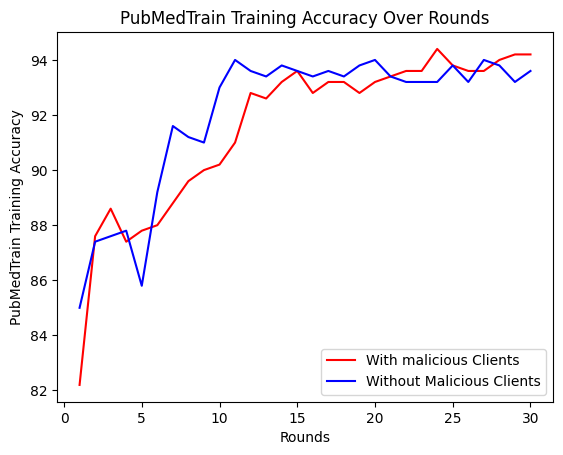

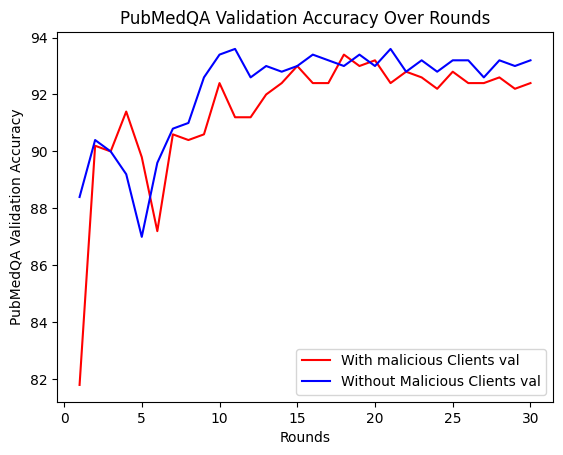

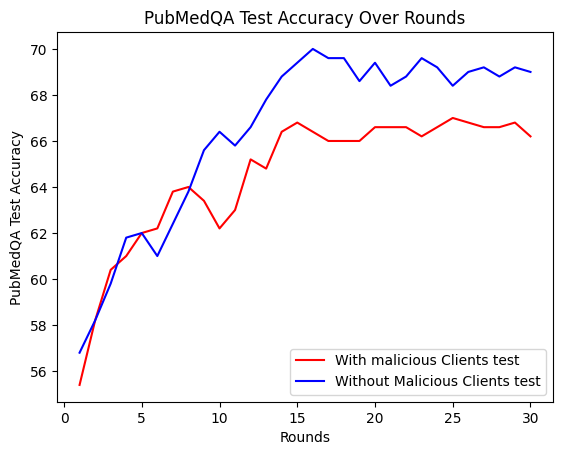

In [11]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-315']['pubmedtrain']
with_malicious_val = run_datas['FED-315']['pubmedval']
with_malicious_test = run_datas['FED-315']['pubmedqa']
without_malicious_train = run_datas['FED-314']['pubmedtrain']
without_malicious_val = run_datas['FED-314']['pubmedval']
without_malicious_test = run_datas['FED-314']['pubmedqa']


rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_val = list(with_malicious_val.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())
without_scores_val = list(without_malicious_val.values())

print(len(with_scores_train), len(with_scores_val), len(with_scores_test), len(without_scores_train), len(without_scores_val), len(without_scores_test))

plt.plot(rounds, with_scores_train, label='With malicious Clients', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedTrain Training Accuracy')
plt.title('PubMedTrain Training Accuracy Over Rounds')
# plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_val, label='With malicious Clients val', color='red')
plt.plot(rounds, without_scores_val, label='Without Malicious Clients val', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Validation Accuracy')
plt.title('PubMedQA Validation Accuracy Over Rounds')
plt.legend()
plt.show()

plt.plot(rounds, with_scores_test, label='With malicious Clients test', color='red')
plt.plot(rounds, without_scores_test, label='Without Malicious Clients test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Test Accuracy')
plt.title('PubMedQA Test Accuracy Over Rounds')
plt.legend()
plt.show()

# plot line with max value
# plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')

# plt.ylabel('SST-2 Test Accuracy')
# plt.title('SST-2 Test Accuracy Over Rounds')
# plt.legend()
# plt.show()

30 30 30 30 30 30


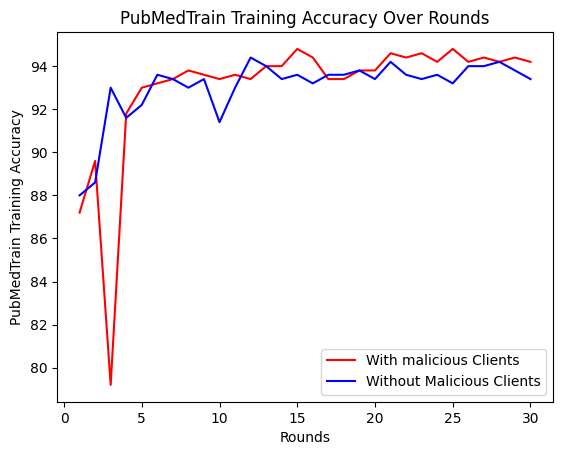

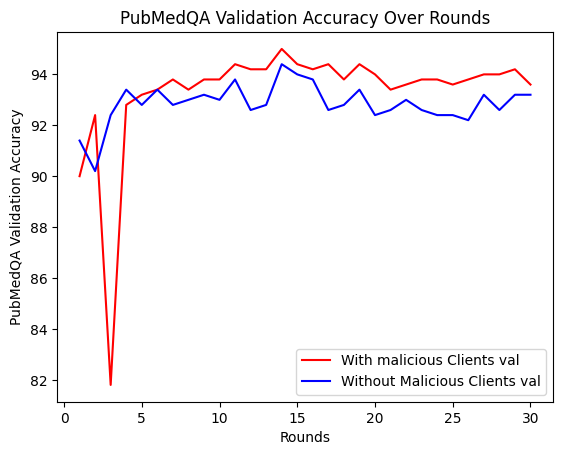

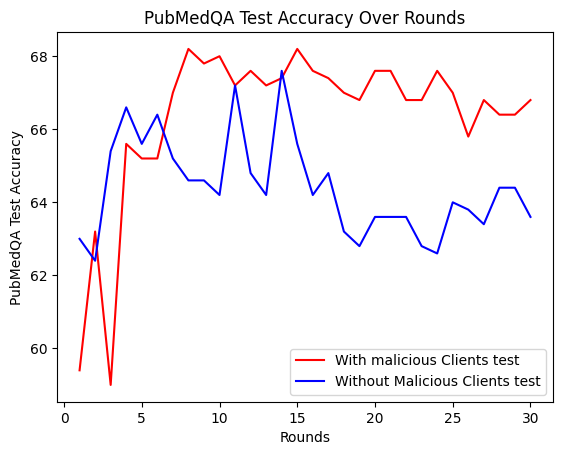

In [13]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-313']['pubmedtrain']
with_malicious_val = run_datas['FED-313']['pubmedval']
with_malicious_test = run_datas['FED-313']['pubmedqa']
without_malicious_train = run_datas['FED-316']['pubmedtrain']
without_malicious_val = run_datas['FED-316']['pubmedval']
without_malicious_test = run_datas['FED-316']['pubmedqa']


rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_val = list(with_malicious_val.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())
without_scores_val = list(without_malicious_val.values())

print(len(with_scores_train), len(with_scores_val), len(with_scores_test), len(without_scores_train), len(without_scores_val), len(without_scores_test))

plt.plot(rounds, with_scores_train, label='With malicious Clients', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedTrain Training Accuracy')
plt.title('PubMedTrain Training Accuracy Over Rounds')
# plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_val, label='With malicious Clients val', color='red')
plt.plot(rounds, without_scores_val, label='Without Malicious Clients val', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Validation Accuracy')
plt.title('PubMedQA Validation Accuracy Over Rounds')
plt.legend()
plt.show()

plt.plot(rounds, with_scores_test, label='With malicious Clients test', color='red')
plt.plot(rounds, without_scores_test, label='Without Malicious Clients test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Test Accuracy')
plt.title('PubMedQA Test Accuracy Over Rounds')
plt.legend()
plt.show()

# plot line with max value
# plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')

# plt.ylabel('SST-2 Test Accuracy')
# plt.title('SST-2 Test Accuracy Over Rounds')
# plt.legend()
# plt.show()

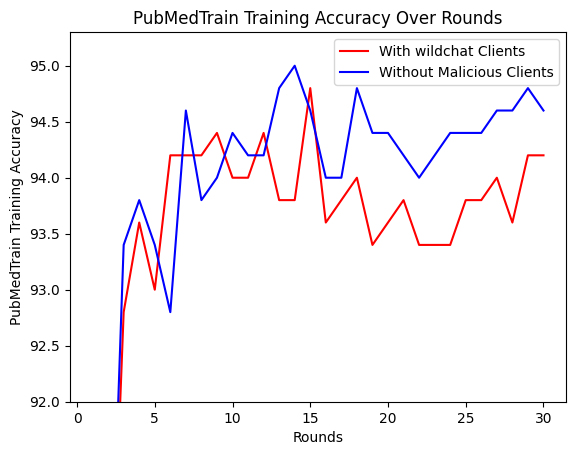

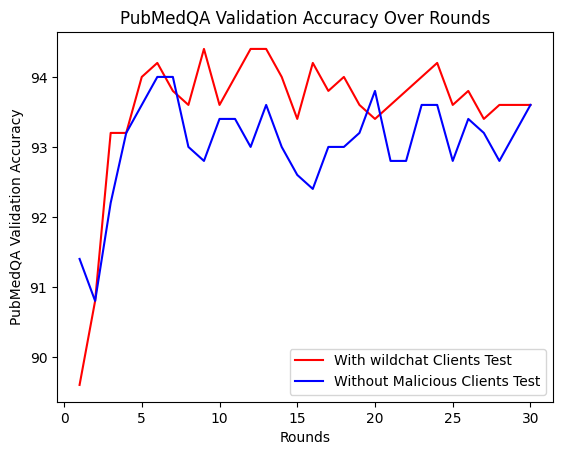

In [15]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-307']['pubmedtrain']
with_malicious_test = run_datas['FED-307']['pubmedval']
without_malicious_train = run_datas['FED-245']['pubmedtrain']
without_malicious_test = run_datas['FED-245']['pubmedval']

rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())

plt.plot(rounds, with_scores_train, label='With wildchat Clients', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedTrain Training Accuracy')
plt.title('PubMedTrain Training Accuracy Over Rounds')
plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_test, label='With wildchat Clients Test', color='red')
plt.plot(without_malicious_test.keys(), without_scores_test, label='Without Malicious Clients Test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Validation Accuracy')
plt.title('PubMedQA Validation Accuracy Over Rounds')
plt.legend()
plt.show()
# plot line with max value
# plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')

# plt.ylabel('SST-2 Test Accuracy')
# plt.title('SST-2 Test Accuracy Over Rounds')
# plt.legend()
# plt.show()

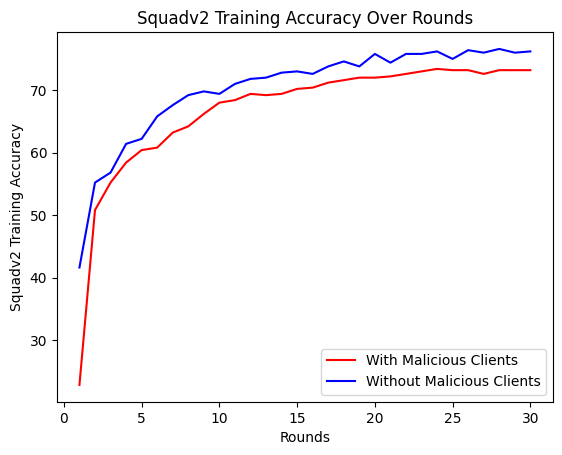

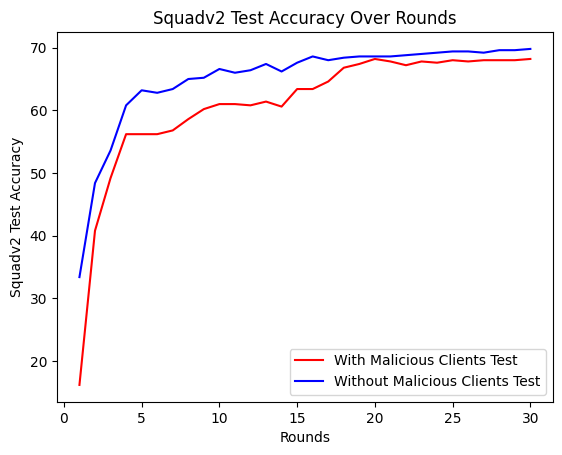

In [ ]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-286']['squadv2train']
with_malicious_test = run_datas['FED-286']['squad_v2']
without_malicious_train = run_datas['FED-244']['squadv2train']
without_malicious_test = run_datas['FED-244']['squad_v2']

rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())

plt.plot(rounds, with_scores_train, label='With Malicious Clients', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('Squadv2 Training Accuracy')
plt.title('Squadv2 Training Accuracy Over Rounds')
# plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_test, label='With Malicious Clients Test', color='red')
plt.plot(without_malicious_test.keys(), without_scores_test, label='Without Malicious Clients Test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('Squadv2 Test Accuracy')
plt.title('Squadv2 Test Accuracy Over Rounds')
plt.legend()
plt.show()
# plot line with max value
# plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')

# plt.ylabel('SST-2 Test Accuracy')
# plt.title('SST-2 Test Accuracy Over Rounds')
# plt.legend()
# plt.show()

In [4]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-287']['pubmedtrain']
with_malicious_test = run_datas['FED-287']['pubmedqa']
without_malicious_train = run_datas['FED-245']['pubmedtrain']
without_malicious_test = run_datas['FED-245']['pubmedqa']

rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())

plt.plot(rounds, with_scores_train, label='With Malicious Clients', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedTrain Training Accuracy')
plt.title('PubMedTrain Training Accuracy Over Rounds')
plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_test, label='With Malicious Clients Test', color='red')
plt.plot(without_malicious_test.keys(), without_scores_test, label='Without Malicious Clients Test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Test Accuracy')
plt.title('PubMedQA Test Accuracy Over Rounds')
plt.legend()
plt.show()
# plot line with max value
# plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')

# plt.ylabel('SST-2 Test Accuracy')
# plt.title('SST-2 Test Accuracy Over Rounds')
# plt.legend()
# plt.show()

KeyError: 'FED-287'

In [5]:
import matplotlib.pyplot as plt
with_malicious_train = run_datas['FED-303']['pubmedtrain']
with_malicious_test = run_datas['FED-303']['pubmedqa']
without_malicious_train = run_datas['FED-245']['pubmedtrain']
without_malicious_test = run_datas['FED-245']['pubmedqa']

rounds = list(with_malicious_train.keys())
with_scores_train = list(with_malicious_train.values())
with_scores_test = list(with_malicious_test.values())
without_scores_train = list(without_malicious_train.values())
without_scores_test = list(without_malicious_test.values())

plt.plot(rounds, with_scores_train, label='With extra PubmedQA Clients', color='red')
plt.plot(list(without_malicious_train.keys()), without_scores_train, label='Without Malicious Clients', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedTrain Training Accuracy')
plt.title('PubMedTrain Training Accuracy Over Rounds')
plt.ylim(92, 95.3)
plt.legend()
plt.show()

plt.plot(with_malicious_test.keys(), with_scores_test, label='With extra PubmedQA Clients Test', color='red')
plt.plot(without_malicious_test.keys(), without_scores_test, label='Without Malicious Clients Test', color='blue')
plt.xlabel('Rounds')
plt.ylabel('PubMedQA Test Accuracy')
plt.title('PubMedQA Test Accuracy Over Rounds')
plt.legend()
plt.show()

KeyError: 'FED-303'

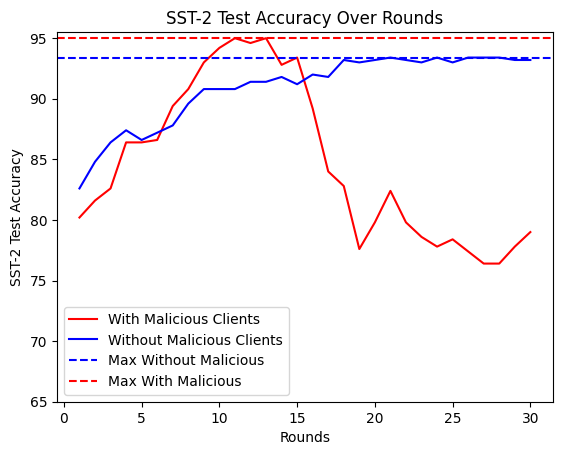

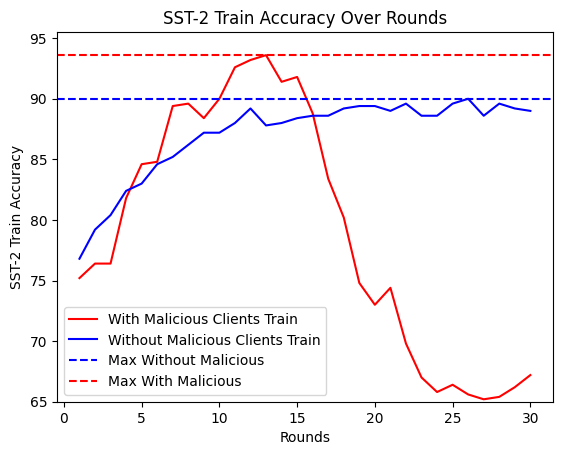

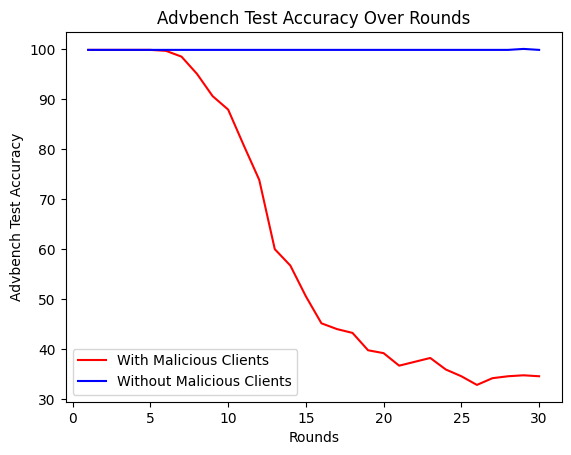

In [6]:
import matplotlib.pyplot as plt
with_malicious = run_datas['FED-310']['sst2']
without_malicious = run_datas['FED-309']['sst2']

with_malicious_train = run_datas['FED-310']['ssttrain']
without_malicious_train = run_datas['FED-309']['ssttrain']

rounds = list(with_malicious.keys())
with_scores = list(with_malicious.values())
without_scores = list(without_malicious.values())

with_scores_train = list(with_malicious_train.values())
without_scores_train = list(without_malicious_train.values())

plt.plot(rounds, with_scores, label='With Malicious Clients', color='red')
plt.plot(rounds, without_scores, label='Without Malicious Clients', color='blue')
# plot line with max value
plt.axhline(y=max(without_scores), linestyle='--', label='Max Without Malicious', color='blue')    
plt.axhline(y=max(with_scores), linestyle='--', label='Max With Malicious', color='red')
plt.xlabel('Rounds')
plt.ylabel('SST-2 Test Accuracy')
plt.title('SST-2 Test Accuracy Over Rounds')
plt.ylim(65, 95.5)
plt.legend()
plt.show()

plt.plot(rounds, with_scores_train, label='With Malicious Clients Train', color='red')
plt.plot(rounds, without_scores_train, label='Without Malicious Clients Train', color='blue')
# plot line with max value
plt.axhline(y=max(without_scores_train), linestyle='--', label='Max Without Malicious', color='blue')    
plt.axhline(y=max(with_scores_train), linestyle='--', label='Max With Malicious', color='red')
plt.xlabel('Rounds')
plt.ylabel('SST-2 Train Accuracy')
plt.title('SST-2 Train Accuracy Over Rounds')
plt.ylim(65, 95.5)
plt.legend()
plt.show()  

# also plot advbench results
with_malicious = run_datas['FED-310']['advbench']
without_malicious = run_datas['FED-309']['advbench']
rounds = list(with_malicious.keys())
with_scores = list(with_malicious.values())
without_scores = list(without_malicious.values())
plt.plot(rounds, with_scores, label='With Malicious Clients', color='red')
plt.plot(rounds, without_scores, label='Without Malicious Clients', color='blue')
# plot line with max value
# plt.axhline(y=max(without_scores), linestyle='--', label='Max Without Malicious', color='blue')    
# plt.axhline(y=max(with_scores), linestyle='--', label='Max With Malicious', color='red')
plt.xlabel('Rounds')
plt.ylabel('Advbench Test Accuracy')
plt.title('Advbench Test Accuracy Over Rounds')
plt.legend()
plt.show()

# Hessian Print

In [2]:

model_roots = {
               'squad_benign_half':  '/shared/rc/llm-degredation/fedllm/barebones/squad_v27_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20251201225922/checkpoint-15',
               'squad_benign':  '/shared/rc/llm-degredation/fedllm/barebones/squad_v27_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20251201225922/checkpoint-30',

               'squad_malicious_half': '/shared/rc/llm-degredation/fedllm/barebones/squad_v27_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251208190114/checkpoint-15', 
               'squad_malicious': '/shared/rc/llm-degredation/fedllm/barebones/squad_v27_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251208190114/checkpoint-30', 

               'pubmed_benign_half': '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20251201230014/checkpoint-15',
               'pubmed_benign': '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20251201230014/checkpoint-30',

               'pubmed_malicious_half': '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251208190205/checkpoint-15',
               'pubmed_malicious': '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251208190205/checkpoint-30'
               }

projections = {
    'base': 'project_matrix_safelora_torch.float32.pkl',
    'base_correct': 'project_matrix_safelora_torch.float32_correct.pkl',
    'harmful': 'project_matrix_safelora_torch.float32_harmful_systemprompt_backup.pkl',
    'harmful_correct': 'project_matrix_safelora_torch.float32_harmful_systemprompt_correct.pkl',
}


In [6]:
# metrics = ['metric_sum', 'metric_sum_bc', 'metric_sum_bic', 'metric_sum_norm', 'metric_sum_bc_norm', 'metric_sum_bic_norm', 'sum_norm', 'sum_bc_norm', 'sum_bic_norm']

# metric_name_maps = ['f(ΔW)', 'f(CΔW)', 'f((I-C)ΔW)', 'f(ΔW_norm)', 'f(CΔW_norm)', 'f((I-C)ΔW_norm)', 'norm(ΔW)', 'norm(CΔW)', 'norm((I-C)ΔW)']

# metrics = ['metric_sum_bic', 'metric_sum_bic_norm', 'sum_bic_norm']

# metric_name_maps = ['f((I-C)ΔW)','f((I-C)ΔW_norm)', 'norm((I-C)ΔW)']

metrics = ['metric_sum_bc', 'metric_sum_bc_norm', 'sum_bc_norm']

metric_name_maps = ['f(CΔW)', 'f(CΔW_norm)',  'norm(CΔW)']

# metrics = ['metric_sum',  'metric_sum_norm', 'sum_norm']

# metric_name_maps = ['f(ΔW)', 'f(ΔW_norm)', 'norm(ΔW)',]

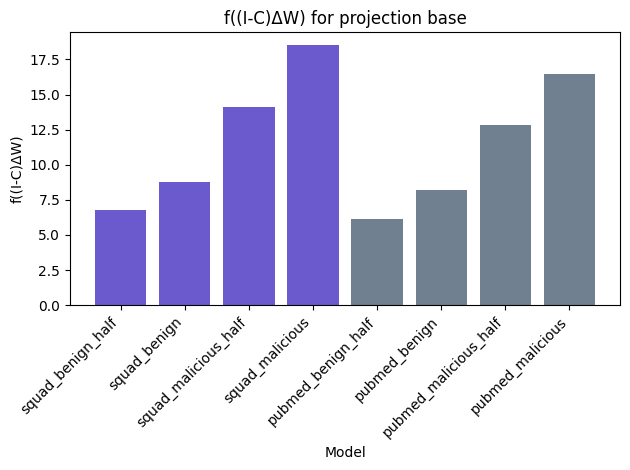

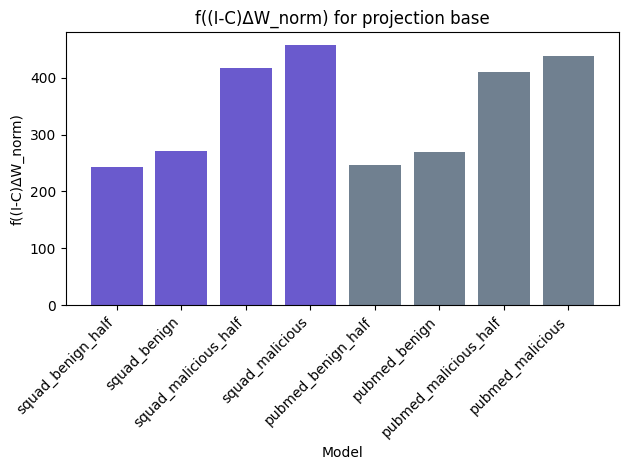

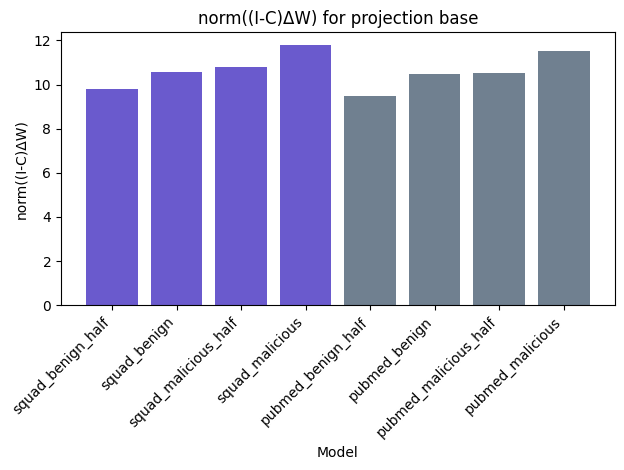

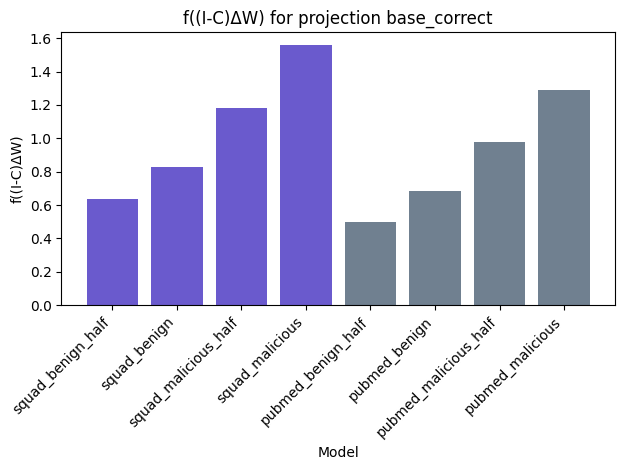

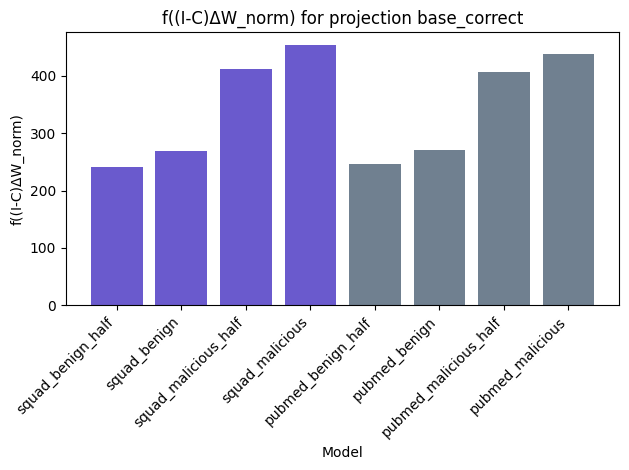

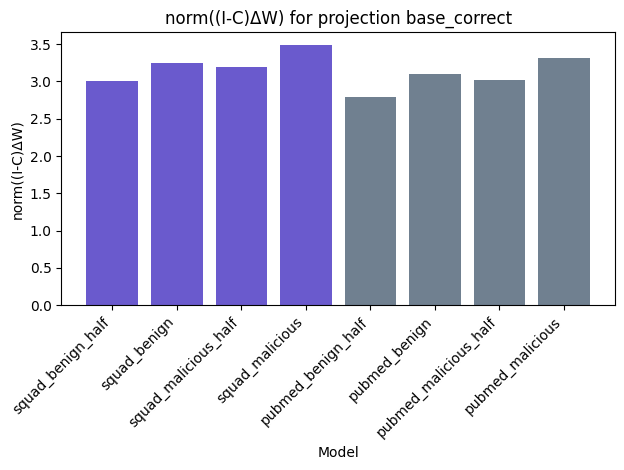

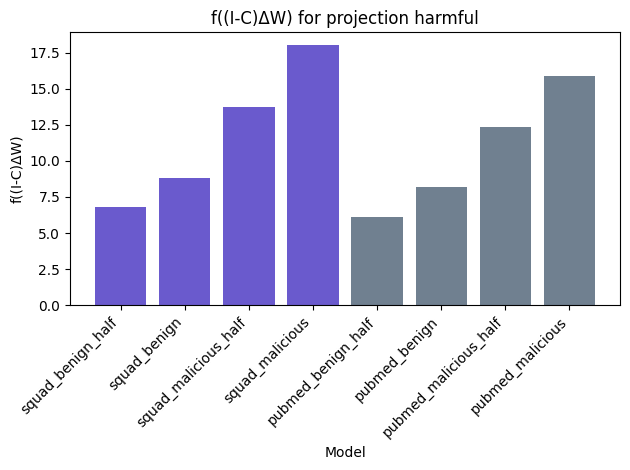

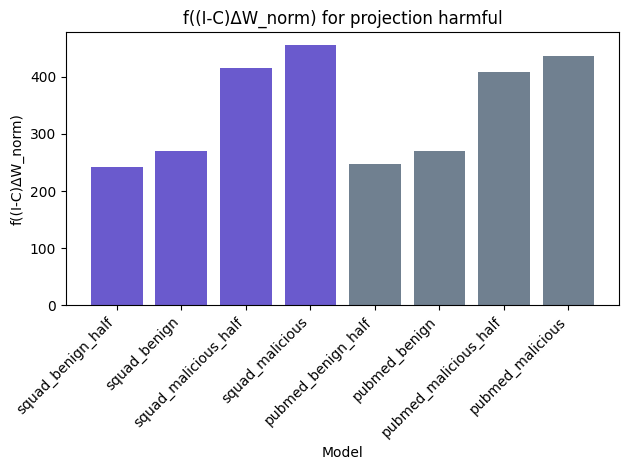

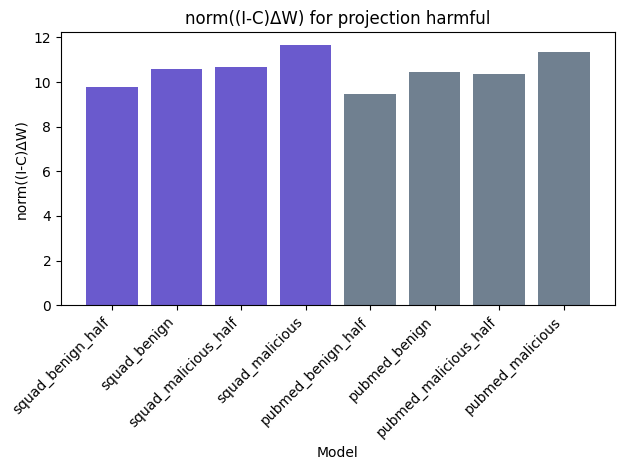

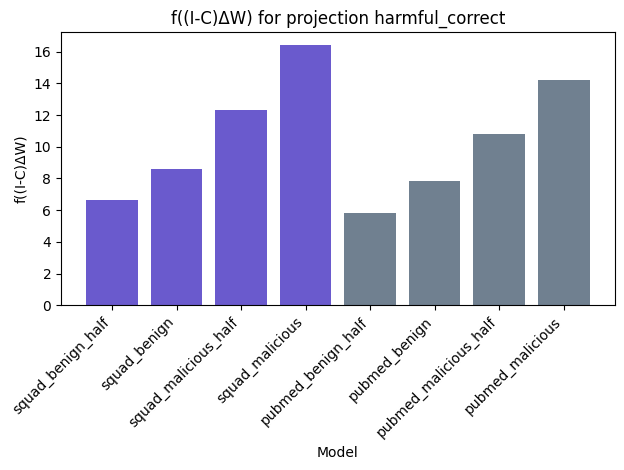

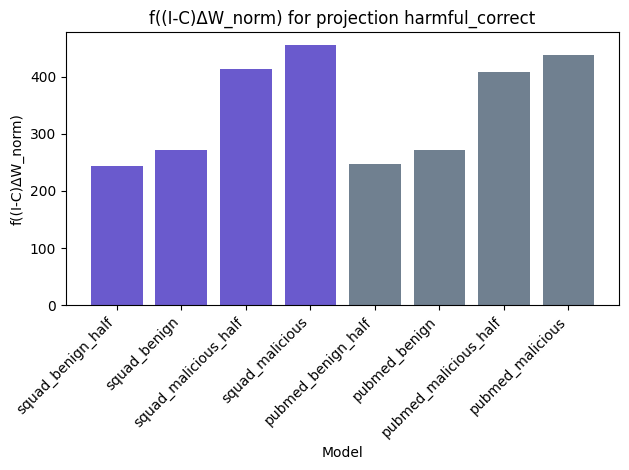

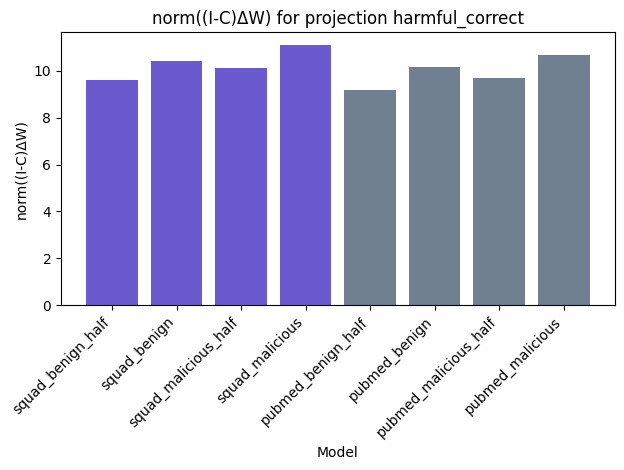

In [5]:
import pickle
import matplotlib.pyplot as plt

for projection in projections.keys():
    with open(f"c_decomposition_drift_metrics_{projection}.pkl", "rb") as f:
        data = pickle.load(f)

    for i, metric in enumerate(metrics):
        ks = list(model_roots.keys())
        ys = [float(data[projection][k]["summary_stats"][metric]) for k in ks]

        colors = ["slategrey" if "pubmed" in k.lower() else "slateblue" for k in ks]

        plt.bar(ks, ys, color=colors)
        plt.xlabel("Model")
        plt.ylabel(metric_name_maps[i])
        plt.title(f"{metric_name_maps[i]} for projection {projection}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
                # plot a bar chart comparing different keys for same metric 
        


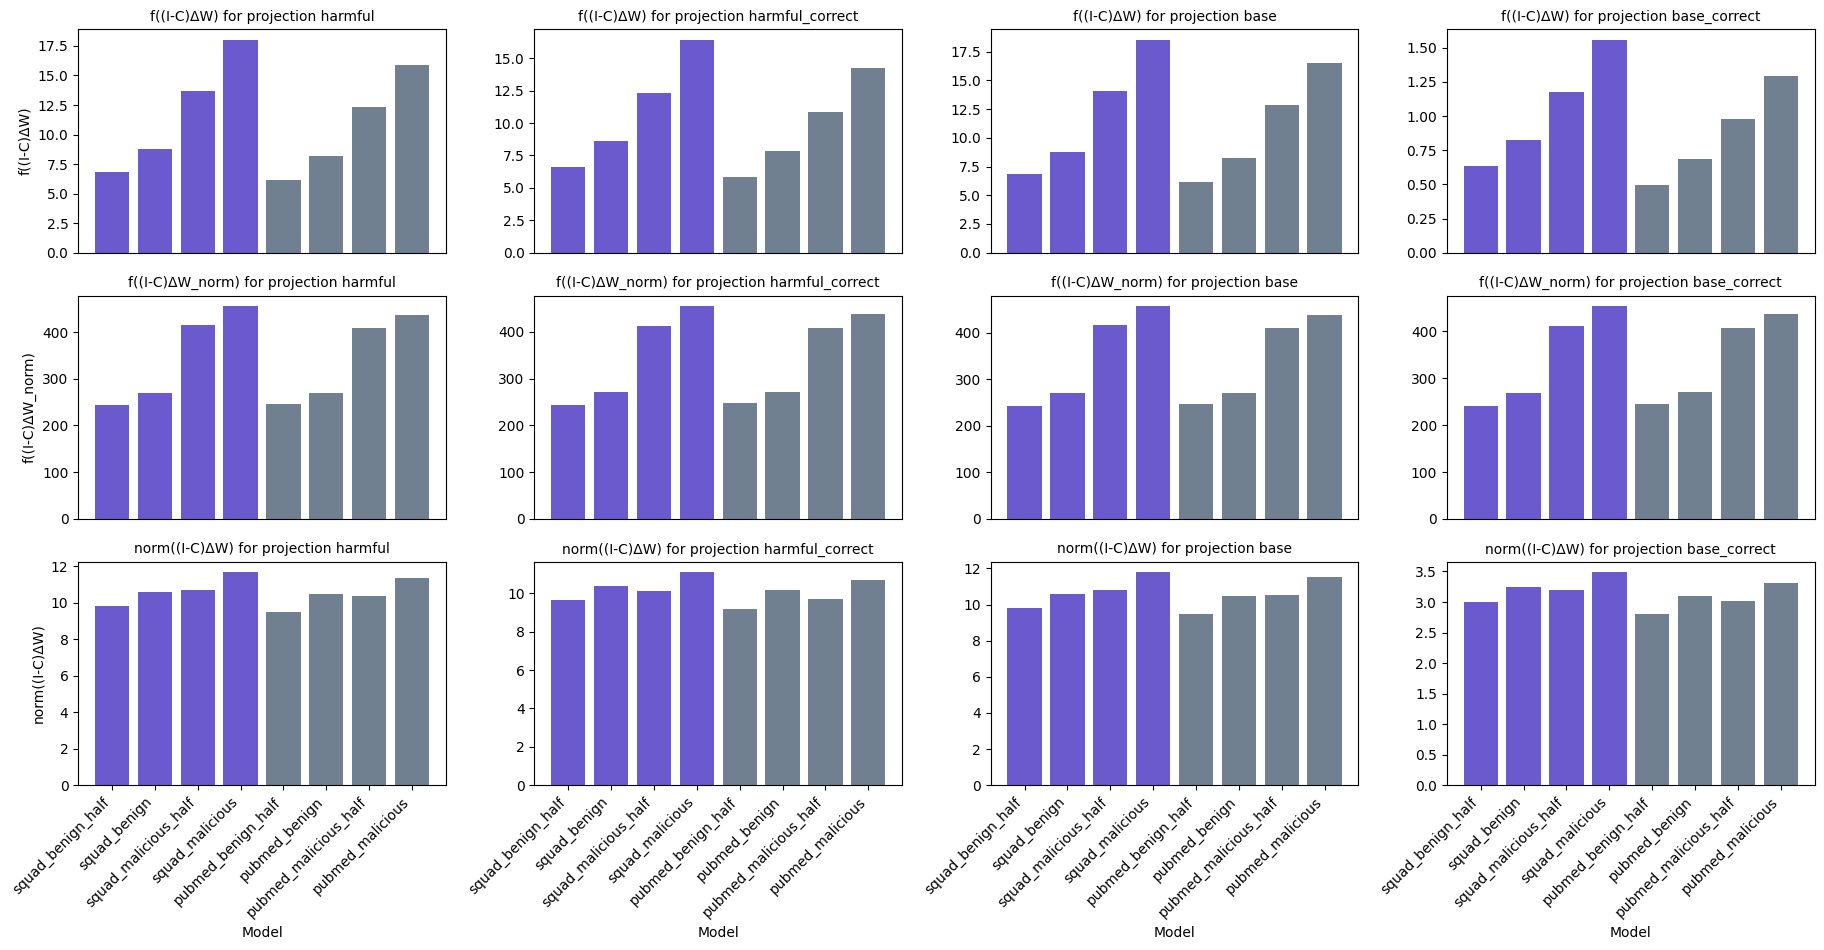

In [4]:
import pickle
import matplotlib.pyplot as plt

# --- control the grid order (to match your screenshot) ---
projection_order = ["harmful", "harmful_correct", "base", "base_correct"]

ks = list(model_roots.keys())
colors = ["slategrey" if "pubmed" in k.lower() else "slateblue" for k in ks]
x = range(len(ks))

nrows = len(metrics)
ncols = len(projection_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.6 * ncols, 3.2 * nrows),
    sharex=True,
)

# make axes always 2D
if nrows == 1:
    axes = [axes]
if ncols == 1:
    axes = [[ax] for ax in axes]

for c, proj in enumerate(projection_order):
    with open(f"c_decomposition_drift_metrics_{proj}.pkl", "rb") as f:
        data = pickle.load(f)

    for r, metric in enumerate(metrics):
        ax = axes[r][c]
        ys = [float(data[proj][k]["summary_stats"][metric]) for k in ks]

        ax.bar(x, ys, color=colors)
        ax.set_title(f"{metric_name_maps[r]} for projection {proj}", fontsize=10)

        if c == 0:
            ax.set_ylabel(metric_name_maps[r])

        # only show x tick labels on bottom row
        if r == nrows - 1:
            ax.set_xticks(list(x))
            ax.set_xticklabels(ks, rotation=45, ha="right")
            ax.set_xlabel("Model")
        else:
            ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

fig.tight_layout()
plt.show()


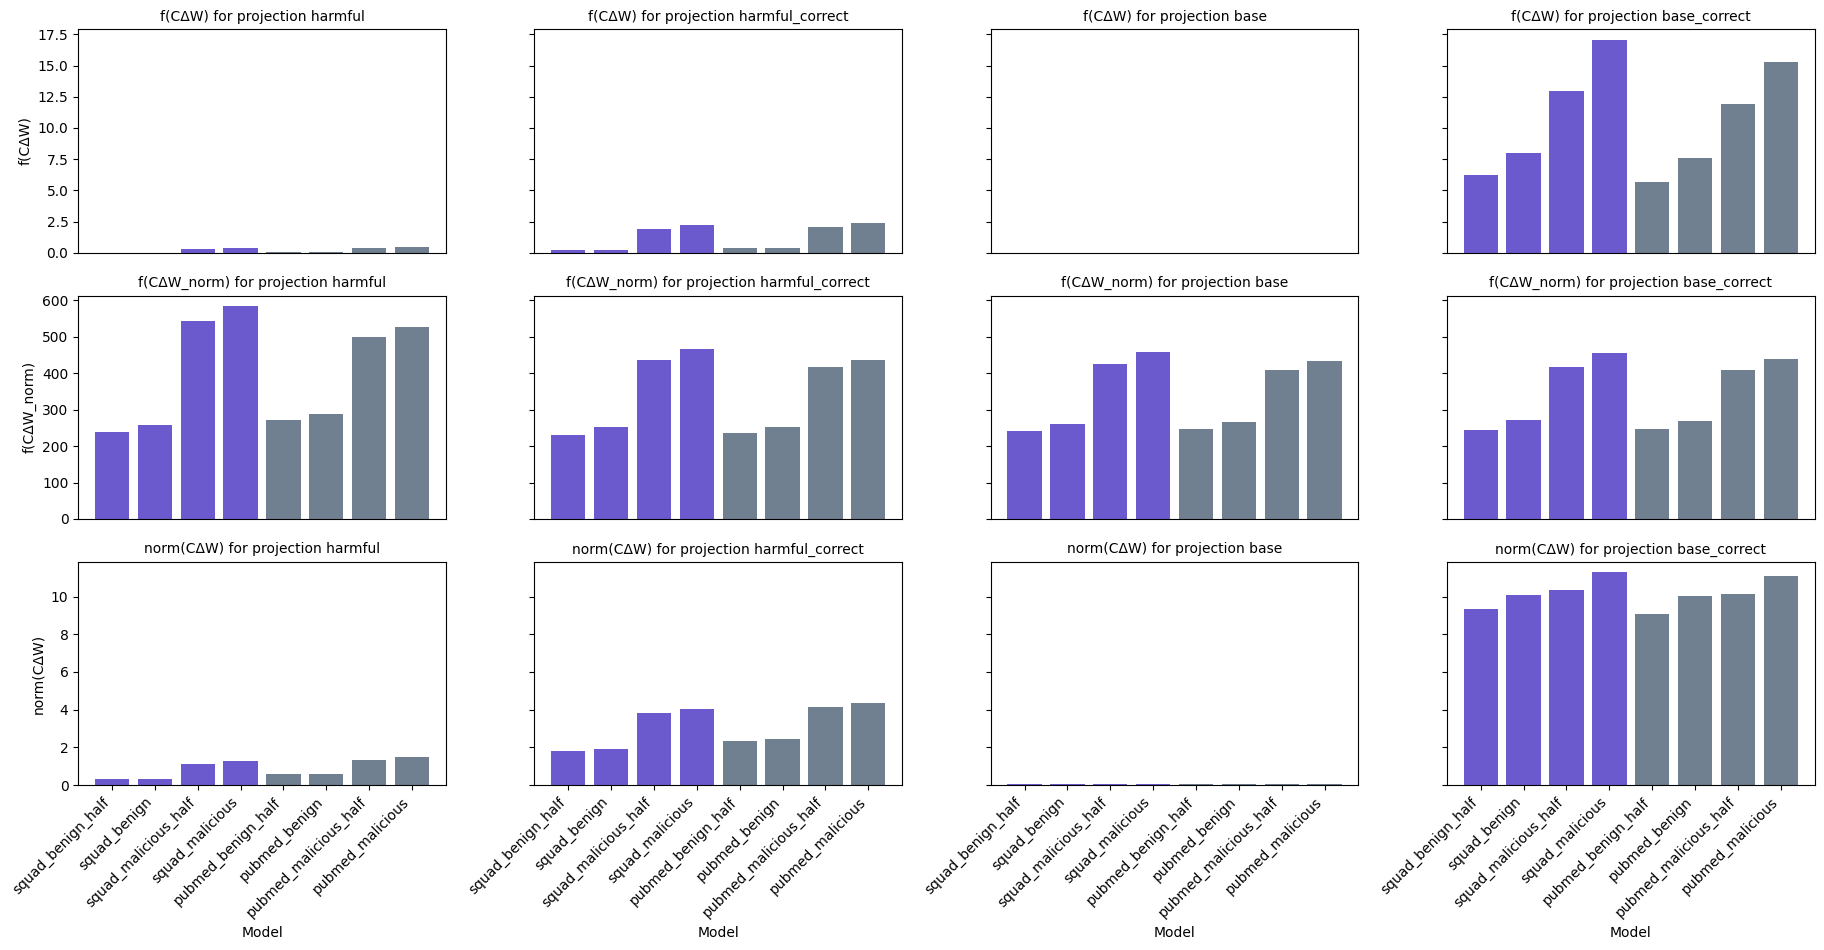

In [7]:
import pickle
import matplotlib.pyplot as plt

# --- control the grid order (to match your screenshot) ---
projection_order = ["harmful", "harmful_correct", "base", "base_correct"]

ks = list(model_roots.keys())
colors = ["slategrey" if "pubmed" in k.lower() else "slateblue" for k in ks]
x = range(len(ks))

nrows = len(metrics)
ncols = len(projection_order)

# ✅ share y-axis within each row (same metric across projections)
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.6 * ncols, 3.2 * nrows),
    sharex=True,
    sharey="row",
)

# normalize axes to 2D
if nrows == 1:
    axes = [axes]
if ncols == 1:
    axes = [[ax] for ax in axes]

for c, proj in enumerate(projection_order):
    with open(f"c_decomposition_drift_metrics_{proj}.pkl", "rb") as f:
        data = pickle.load(f)

    for r, metric in enumerate(metrics):
        ax = axes[r][c]
        ys = [float(data[proj][k]["summary_stats"][metric]) for k in ks]

        ax.bar(x, ys, color=colors)
        ax.set_title(f"{metric_name_maps[r]} for projection {proj}", fontsize=10)

        # y-label only on the left-most plot of each row
        if c == 0:
            ax.set_ylabel(metric_name_maps[r])

        # x tick labels only on the bottom row
        if r == nrows - 1:
            ax.set_xticks(list(x))
            ax.set_xticklabels(ks, rotation=45, ha="right")
            ax.set_xlabel("Model")
        else:
            ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

fig.tight_layout()
plt.show()


In [17]:
metrics = data[projection]['squad_malicious']['summary_stats'].keys()

In [18]:
metrics

dict_keys(['metric_sum', 'metric_sum_bc', 'metric_sum_bic', 'metric_sum_norm', 'metric_sum_bc_norm', 'metric_sum_bic_norm', 'sum_norm', 'sum_bc_norm', 'sum_bic_norm'])

In [16]:
projection

'harmful_correct'